In [1]:
import pandas as pd
import importlib
import data_audit

importlib.reload(data_audit)



df = pd.read_csv("restaurant_clf.csv")

# url: URL адрес на ресторанта в Restaurant GPT.
# address: Адрес на ресторанта.
# name: Име на ресторанта.
# online_order: Дали е налична опция за онлайн поръчка.
# book_table: Дали е налична опция за онлайн резервация на маса.
# votes: Общ брой гласове/оценки за ресторанта.
# phone: Телефонен номер на ресторанта.
# location: Кварталът, в който се намира ресторантът.
# rest_type: Тип на обекта.
# dish_liked: Списък с ястия, харесвани от клиентите.
# cuisines: Типове кухни, обслужвани от ресторанта.
# approx_cost(for two people): Приблизителна цена за хранене на двама души.
# reviews_list: Списък с ревюта и оценки от клиенти.
# menu_item: Списък с налични елементи от менюто.
# listed_in(type): Тип на хранене.
# listed_in(city): Зоната на града, в която е разположен ресторантът (обикновено по-голяма област от "location").
# rate: Общата агрегирана оценка на ресторанта.


In [2]:
# STOP — do not run unless removed
if False:

    data_audit.create_data_audit(df.drop(columns=['Unnamed: 0','url', 'address', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']), bar_chart_cols=['online_order', 'book_table', 'location', 'rest_type', 'cuisines', 'listed_in(type)', 'listed_in(city)'], hue_column=None)

In [3]:
#Preprocessing data

from sklearn.preprocessing import OneHotEncoder

#Making rates to be numbers
df['rate_clean'] = (
    df['rate']
      .replace('-', pd.NA)     # "-" = missing
      .replace('NEW', pd.NA)   # "NEW" = missing rating
      .str.replace(' ', '', regex=False)
      .str.split('/')
      .str[0]
      .pipe(pd.to_numeric, errors='coerce')
)

print('preprocessed rates')

#creating target column
median_rate = df['rate_clean'].median()
df['above_median_rate'] = (df['rate_clean'] > median_rate).astype(int)

print('created target column')

#Mapping yes/no to 1/0
df['online_order'] = df['online_order'].map({'Yes': 1, 'No': 0})
df['book_table'] = df['book_table'].map({'Yes': 1, 'No': 0})

print('mapped online_order and book_table to 0/1')

# #One-hot encoding categorical features
# df_dummies = pd.get_dummies(df['location'], drop_first=True, dtype=int)
# df = pd.concat([df_dummies, df.drop(columns=['location'])], axis=1)

# print('one-hot encoded location')

# #One-hot encoding categorical features
# df_dummies = pd.get_dummies(df['name'], drop_first=True, dtype=int)
# df = pd.concat([df_dummies, df.drop(columns=['name'])], axis=1)

# print('one-hot encoded name')

# #One-hot encoding categorical features
# df_dummies = pd.get_dummies(df['phone'], drop_first=True, dtype=int)
# df = pd.concat([df_dummies, df.drop(columns=['phone'])], axis=1)

# print('one-hot encoded phone')

# #One-hot encoding categorical features
# df_dummies = pd.get_dummies(df['listed_in(type)'], drop_first=True, dtype=int)
# df = pd.concat([df_dummies, df.drop(columns=['listed_in(type)'])], axis=1)

# print('one-hot encoded listed_in(type)')

# #One-hot encoding categorical features
# df_dummies = pd.get_dummies(df['listed_in(city)'], drop_first=True, dtype=int)
# df = pd.concat([df_dummies, df.drop(columns=['listed_in(city)'])], axis=1)

# print('one-hot encoded listed_in(city)')

single_cat_cols = ['location', 'name', 'phone', 'listed_in(city)', 'listed_in(type)']

ohe = OneHotEncoder(drop='first', sparse_output=True, dtype=int)

ohe_matrix = ohe.fit_transform(df[single_cat_cols])

from scipy.sparse import csr_matrix
import numpy as np

def list_to_sparse(df_list, prefix=None):
    """
    Convert a Series of lists (multi-label) into a CSR sparse matrix.
    """
    # Create mapping: category → column index
    unique_values = sorted({item for sublist in df_list for item in sublist})
    col_index = {cat: i for i, cat in enumerate(unique_values)}

    # Build COO components
    rows = []
    cols = []
    data = []

    for row_idx, items in enumerate(df_list):
        for item in items:
            rows.append(row_idx)
            cols.append(col_index[item])
            data.append(1)

    # Convert to sparse CSR matrix
    mat = csr_matrix((data, (rows, cols)),
                     shape=(len(df_list), len(unique_values)),
                     dtype=int)
    return pd.DataFrame.sparse.from_spmatrix(mat, columns=unique_values)


rest_type = list_to_sparse(df, 'rest_type')

print('one-hot encoded rest_type')

dish_liked = list_to_sparse(df, 'dish_liked')

print('one-hot encoded dish_liked')

cuisines = list_to_sparse(df, 'cuisines')

print('one-hot encoded cuisines')

menu_item = list_to_sparse(df, 'menu_item')

print('one-hot encoded menu_item')

preprocessed rates
created target column
mapped online_order and book_table to 0/1
one-hot encoded rest_type
one-hot encoded dish_liked
one-hot encoded cuisines
one-hot encoded menu_item


In [4]:
df = df.drop(columns=['Unnamed: 0'])
print(df.columns)

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)', 'rate_clean',
       'above_median_rate'],
      dtype='object')


In [5]:
y = df['above_median_rate']

ohe_df = pd.DataFrame.sparse.from_spmatrix(
    ohe_matrix,
    columns=ohe.get_feature_names_out(single_cat_cols)
)

df_sparse_all = pd.concat([
    ohe_df,
    rest_type,
    dish_liked,
    cuisines,
    menu_item
], axis=1)


X = pd.concat([
    df_sparse_all,
    df[['online_order', 'book_table', 'votes']]
], axis=1)



In [6]:
print(X.columns.size)

23964


The columns are too many, that's why we will do TruncatedSVD 
so that we can get what are the useful columns and we are not
using PCA, because it's not optimized for sparse matrices.

In [7]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=1)
X_reduced = svd.fit_transform(X)

print(X_reduced.shape[0])

/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


51717


In [8]:
print(X_reduced.shape[1])

1


In [9]:
explained = svd.explained_variance_ratio_.sum()
print("Total variance preserved:", explained)

Total variance preserved: 0.9999925458181222


We are preserving 99.9993% of the variance, so we can be sure that we are preserving most of the information. I also tried doing it with 100
dimensions and it preserved 99.9997%, with 10 and got 99.9994%, with 5 and got 99.9994% and with 2 and got 99.9993%.

In [10]:
import classification
importlib.reload(classification)

# STOP — do not run unless removed
if False:
    X_reduced = pd.DataFrame(X_reduced)
    classification.classify(X_options=[X_reduced], y=y, filename='./model_report.xlsx', diagrams='./diagrams', append=False)



In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

reviews_list = df['reviews_list']

vectorizer = TfidfVectorizer(input='content')
reviews_tfidf = vectorizer.fit_transform(reviews_list)

In [12]:
print(reviews_tfidf.shape)

(51717, 66926)


In [13]:
from sklearn.decomposition import TruncatedSVD

model = TruncatedSVD(n_components=100)
reviews_tfidf_reduced = model.fit_transform(reviews_tfidf)

print("Variance per component:")
print(svd.explained_variance_ratio_)

print("\nTotal variance preserved:")
print(svd.explained_variance_ratio_.sum())

Variance per component:
[0.99999255]

Total variance preserved:
0.9999925458181222


We see that most of the variance is preserved but let's try to use even less components.

In [14]:
model = TruncatedSVD(n_components=5)
reviews_tfidf_reduced = model.fit_transform(reviews_tfidf)

print("Variance per component:")
print(svd.explained_variance_ratio_)

print("\nTotal variance preserved:")
print(svd.explained_variance_ratio_.sum())

Variance per component:
[0.99999255]

Total variance preserved:
0.9999925458181222


In [15]:
model = TruncatedSVD(n_components=2)
reviews_tfidf_reduced = model.fit_transform(reviews_tfidf)

print("Variance per component:")
print(svd.explained_variance_ratio_)

print("\nTotal variance preserved:")
print(svd.explained_variance_ratio_.sum())

Variance per component:
[0.99999255]

Total variance preserved:
0.9999925458181222


So, we will use only this two dimensions if they preserve 99.999% of variance, and also they will be perfect for plotting.

n_components=[1]
Training on cluster size:2
{'params': {'hdbscan__min_cluster_size': [2]}}


/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=30. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed t

Training on cluster size:1000
{'params': {'hdbscan__min_cluster_size': [1000]}}


/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=30. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed t

Training on cluster size:5000
{'params': {'hdbscan__min_cluster_size': [5000]}}


/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=30. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed t

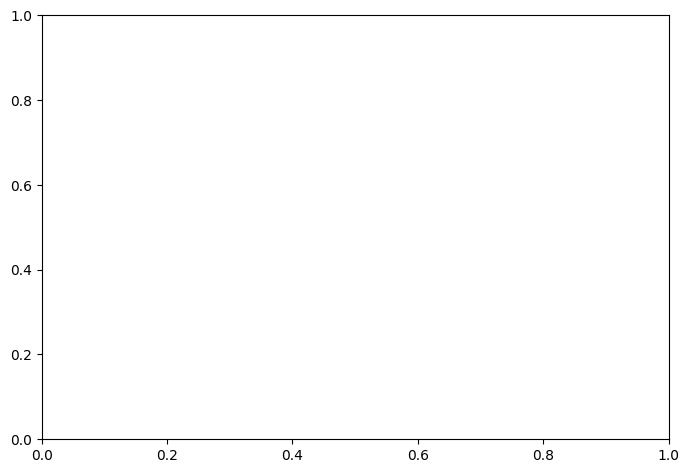

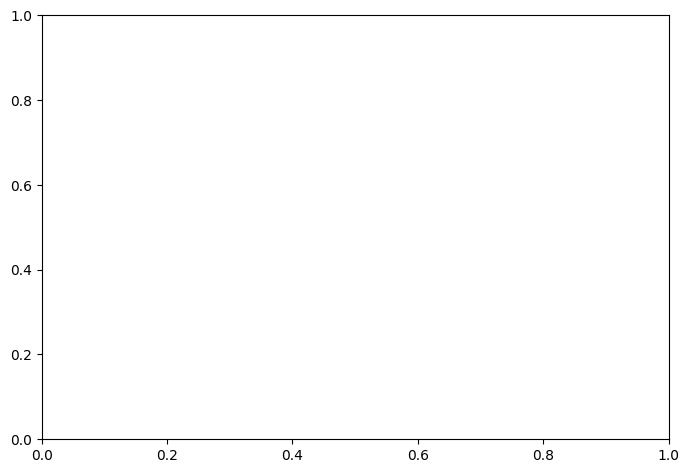

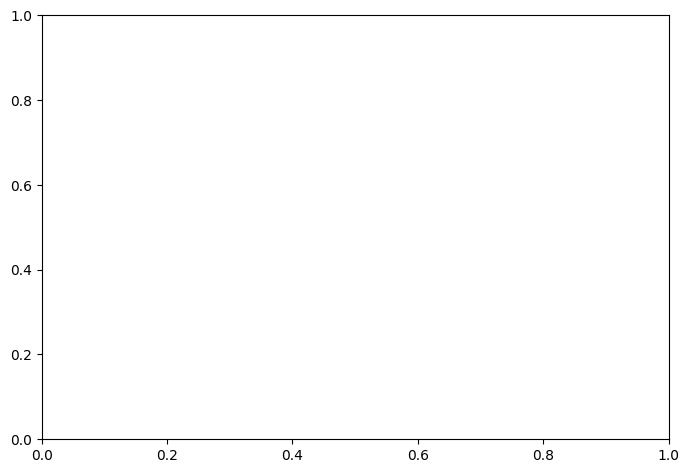

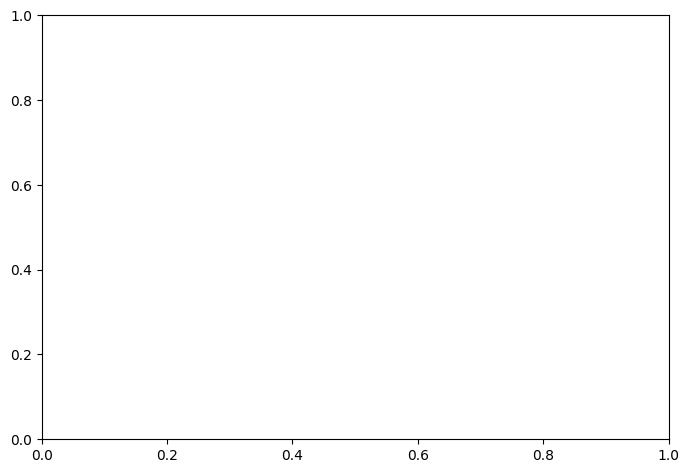

In [24]:
import openpyxl
import clusterization

importlib.reload(clusterization)

filename = './model_report_review_list.xlsx'
diagrams_folder_path = './diagrams'

wb = openpyxl.Workbook()
wb.create_sheet('ModelReport')
ws = wb['ModelReport']

ws.append(['Model', 'Scaling/PCA/t-SNE/TruncatedSVD', 'Number of variables','Hyperparams', 'Inertia', 'Silhouette', 'Silhouette Increase from base model %', 'Silhouette for test data', 'Silhouette for test data increase %','Scatter plot train', 'Dendrogram', 'Scatter plot test', 'PCA variance', 'Cross-Tabulation'])

clusterization.base_model(reviews_tfidf_reduced, ws)

model_options = [
    # 'agglomerative',
    # 'dbscan',
    'hdbscan'
]

data_preprocessing = [
    {'scaling':False,
        'pca':False,
        'tsne': False,
        'truncatedsvd':False},
]

n_components = [1]
print(f'{n_components=}')

cluster_sizes = [2, 1000, 5000]
# cluster_sizes = [2]
reviews_clusterization_models = []

for name in model_options:
    for preprocessing in data_preprocessing:
        for n_component in n_components:
            for cluster_size in cluster_sizes:
                scaling = preprocessing['scaling']
                pca = preprocessing['pca']
                tsne = preprocessing['tsne']
                truncatedsvd = preprocessing['truncatedsvd']

                args = {'params':{'hdbscan__min_cluster_size': [cluster_size]}}
                print(f'Training on cluster size:{cluster_size}')
                
                reviews_clusterization_models.append(clusterization.clusterize(X=reviews_tfidf_reduced, args=args,real_labels=df['above_median_rate'], name=f'{name}{cluster_size}', n_features=n_component, scaling=scaling, pca=pca, tsne=tsne, truncatedsvd=truncatedsvd, ws=ws, clusterization_distance=1.41))

wb.save(filename)

In [25]:
for model in reviews_clusterization_models:
    hdb = model.named_steps["hdbscan"]

    print('INFORMATION PRINT:')

    labels = hdb.labels_

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print("Number of clusters:", n_clusters)

    n_noise = np.sum(labels == -1)
    print("Noise points:", n_noise)

    # Count only non-noise clusters
    valid_labels = labels[labels >= 0]
    cluster_sizes = np.bincount(valid_labels)

    # Get indices of clusters sorted by size (largest first)
    top_k = 20
    largest_clusters_idx = np.argsort(cluster_sizes)[::-1][:top_k]

    # Get corresponding sizes
    largest_clusters_sizes = cluster_sizes[largest_clusters_idx]

    for rank, (cid, size) in enumerate(zip(largest_clusters_idx, largest_clusters_sizes), 1):
        print(f"{rank}. Cluster {cid}: {size} points")





INFORMATION PRINT:
Number of clusters: 8197
Noise points: 4929
1. Cluster 1: 7595 points
2. Cluster 1025: 33 points
3. Cluster 3561: 21 points
4. Cluster 7329: 21 points
5. Cluster 5551: 20 points
6. Cluster 7853: 20 points
7. Cluster 4121: 20 points
8. Cluster 3467: 19 points
9. Cluster 7170: 19 points
10. Cluster 849: 19 points
11. Cluster 5263: 19 points
12. Cluster 7210: 19 points
13. Cluster 4338: 19 points
14. Cluster 7337: 18 points
15. Cluster 3301: 18 points
16. Cluster 4036: 18 points
17. Cluster 5542: 18 points
18. Cluster 6309: 18 points
19. Cluster 1876: 18 points
20. Cluster 4282: 18 points
INFORMATION PRINT:
Number of clusters: 3
Noise points: 10594
1. Cluster 2: 28473 points
2. Cluster 1: 7598 points
3. Cluster 0: 5052 points
INFORMATION PRINT:
Number of clusters: 2
Noise points: 19637
1. Cluster 1: 24461 points
2. Cluster 0: 7619 points


Ok so we got a general idea of what the data looks like, now I will train classification models based on this data to try and predict if the rating will be above average only by looking at the reviews list and after that i will do it by using both the other data and review list.

knn
logistic


/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


cart
xgboost
catboost
0:	learn: 0.6670791	total: 53.7ms	remaining: 107ms
1:	learn: 0.6458460	total: 58.4ms	remaining: 29.2ms
2:	learn: 0.6286124	total: 62.6ms	remaining: 0us
0:	learn: 0.6667324	total: 2.66ms	remaining: 5.32ms
1:	learn: 0.6455947	total: 4.42ms	remaining: 2.21ms
2:	learn: 0.6285089	total: 5.82ms	remaining: 0us
0:	learn: 0.6667985	total: 2.39ms	remaining: 4.77ms
1:	learn: 0.6454059	total: 4.21ms	remaining: 2.1ms
2:	learn: 0.6281395	total: 5.58ms	remaining: 0us
0:	learn: 0.6668668	total: 1.82ms	remaining: 3.63ms
1:	learn: 0.6457681	total: 3.27ms	remaining: 1.64ms
2:	learn: 0.6288104	total: 4.56ms	remaining: 0us
0:	learn: 0.6670191	total: 2.18ms	remaining: 4.36ms
1:	learn: 0.6456205	total: 3.85ms	remaining: 1.92ms
2:	learn: 0.6284505	total: 5.47ms	remaining: 0us
0:	learn: 0.6482670	total: 1.63ms	remaining: 4.89ms
1:	learn: 0.6178932	total: 3.01ms	remaining: 3.01ms
2:	learn: 0.5961935	total: 4.29ms	remaining: 1.43ms
3:	learn: 0.5814912	total: 5.41ms	remaining: 0us
0:	learn: 

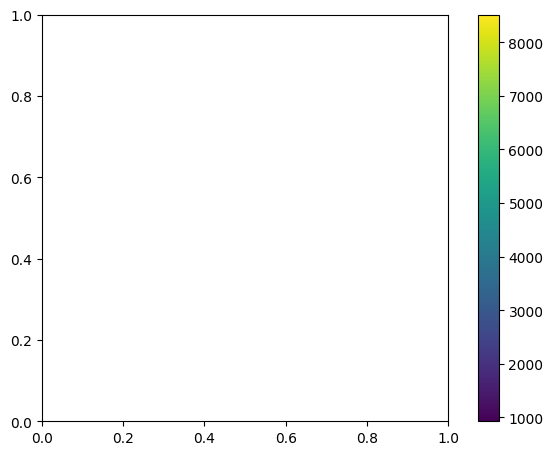

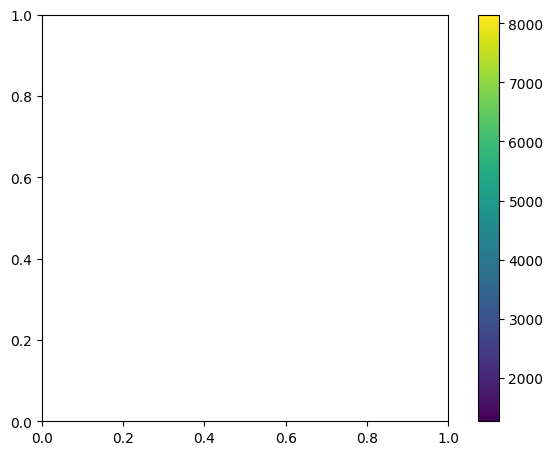

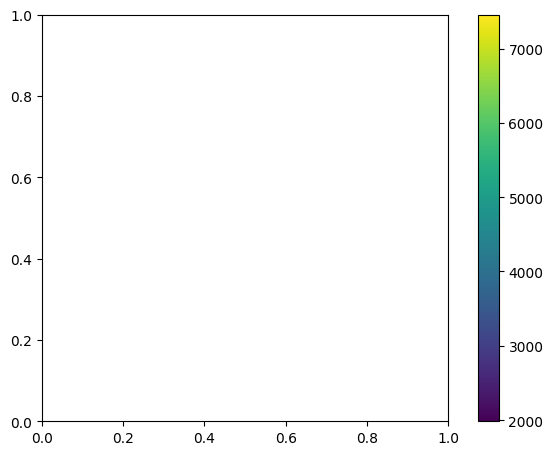

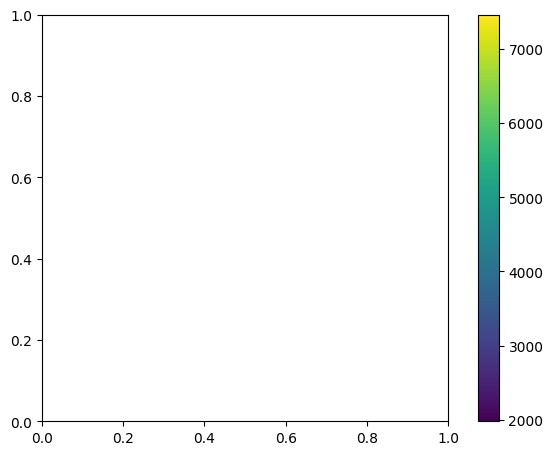

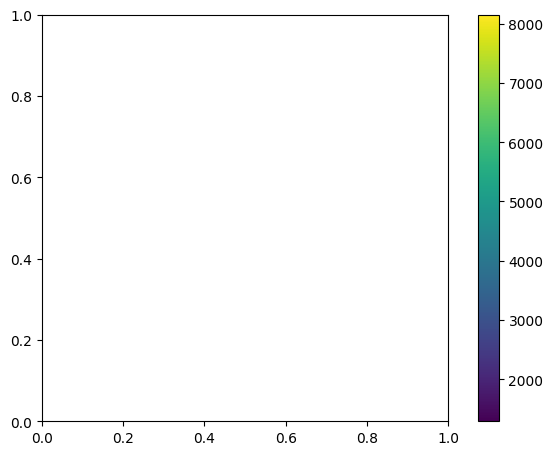

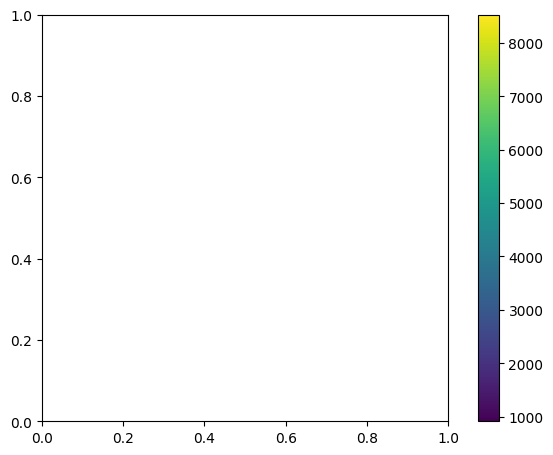

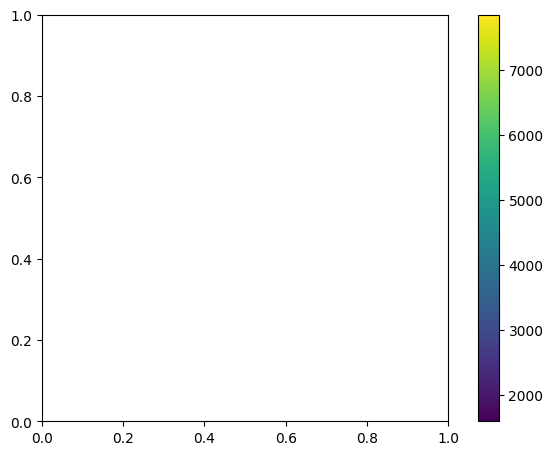

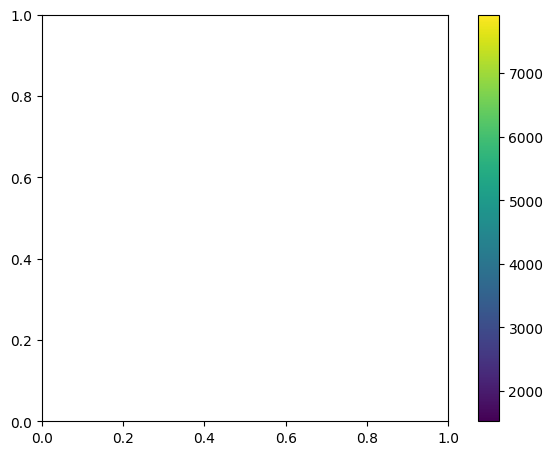

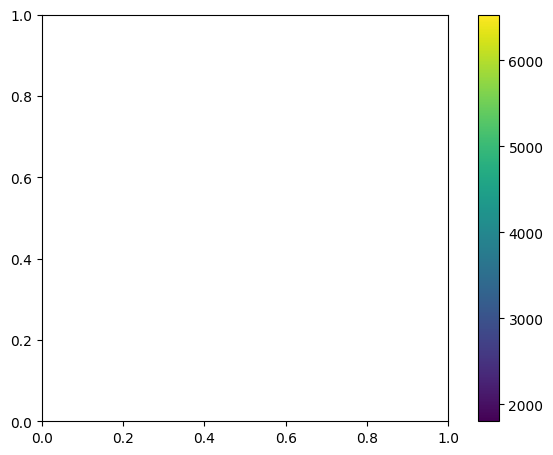

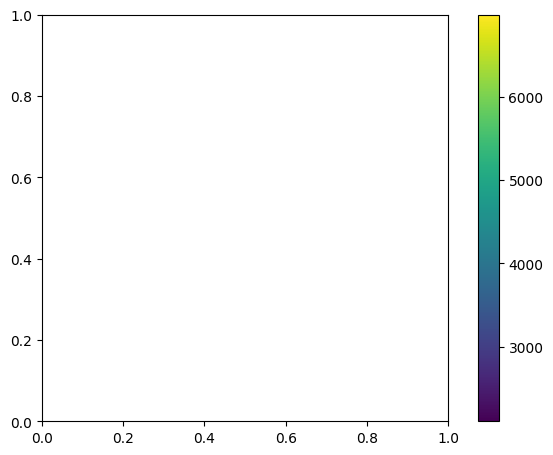

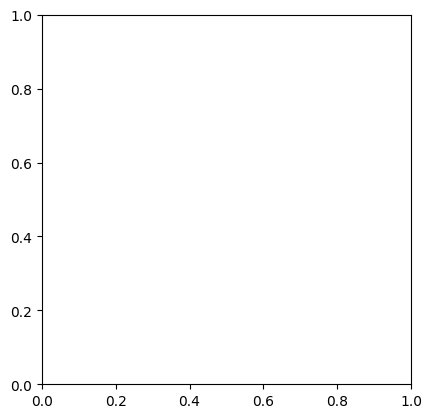

In [27]:
classification.classify(X_options=[pd.DataFrame(reviews_tfidf_reduced)], y=y, filename='./model_report_classification_only_review_list.xlsx', diagrams='./diagrams', append=False)

Now let's use all of the available data.

knn
logistic


/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


cart
xgboost
catboost
0:	learn: 0.5717803	total: 1.12ms	remaining: 6.7ms
1:	learn: 0.4987336	total: 1.94ms	remaining: 4.86ms
2:	learn: 0.4518634	total: 2.87ms	remaining: 3.83ms
3:	learn: 0.4192310	total: 3.79ms	remaining: 2.84ms
4:	learn: 0.3958883	total: 4.69ms	remaining: 1.88ms
5:	learn: 0.3779140	total: 5.6ms	remaining: 933us
6:	learn: 0.3662008	total: 6.53ms	remaining: 0us
0:	learn: 0.5720150	total: 993us	remaining: 5.96ms
1:	learn: 0.4987432	total: 1.78ms	remaining: 4.46ms
2:	learn: 0.4503653	total: 2.6ms	remaining: 3.47ms
3:	learn: 0.4176097	total: 3.37ms	remaining: 2.53ms
4:	learn: 0.3934035	total: 4.16ms	remaining: 1.66ms
5:	learn: 0.3762323	total: 4.99ms	remaining: 832us
6:	learn: 0.3657969	total: 5.84ms	remaining: 0us
0:	learn: 0.5713350	total: 919us	remaining: 5.52ms
1:	learn: 0.4980018	total: 1.67ms	remaining: 4.17ms
2:	learn: 0.4512023	total: 2.46ms	remaining: 3.28ms
3:	learn: 0.4183550	total: 3.28ms	remaining: 2.46ms
4:	learn: 0.3948071	total: 4.09ms	remaining: 1.64ms
5:	

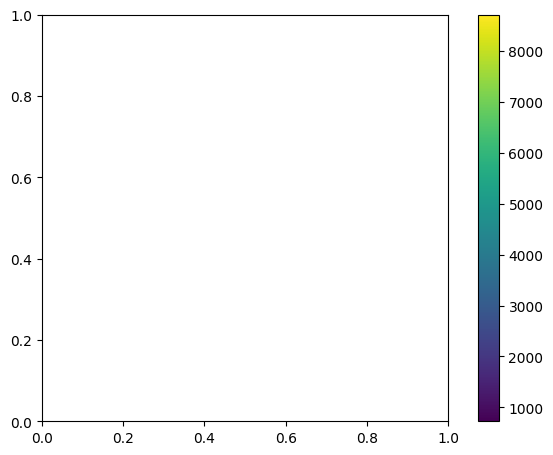

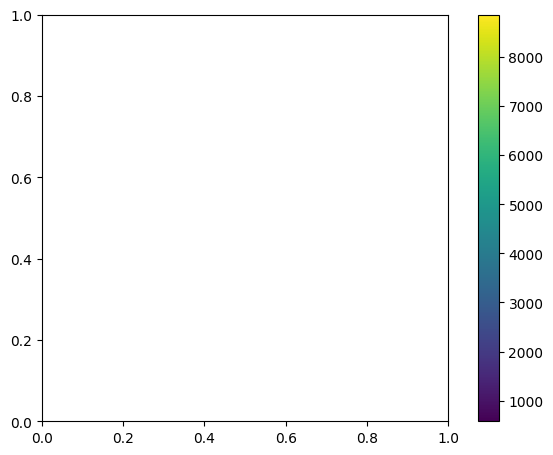

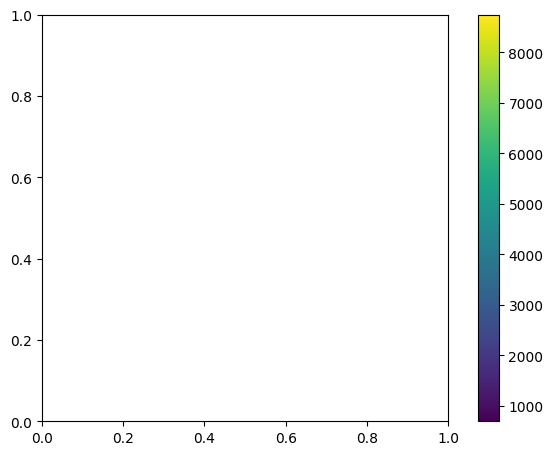

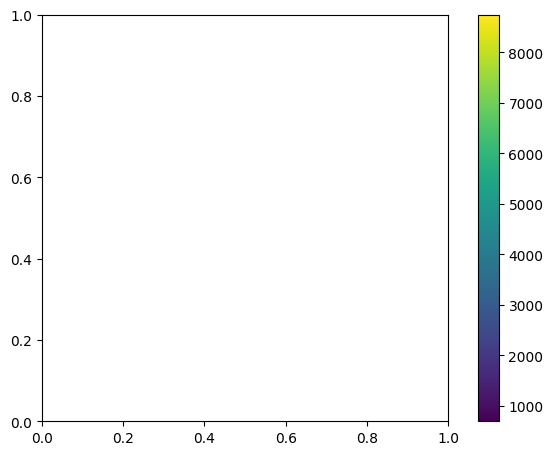

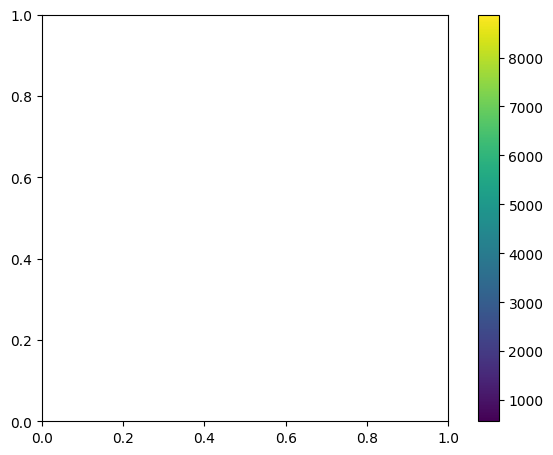

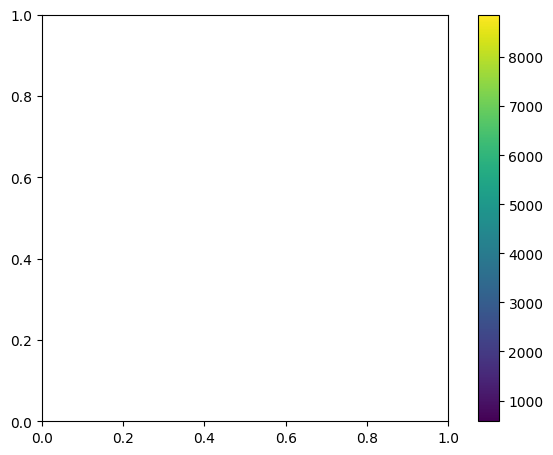

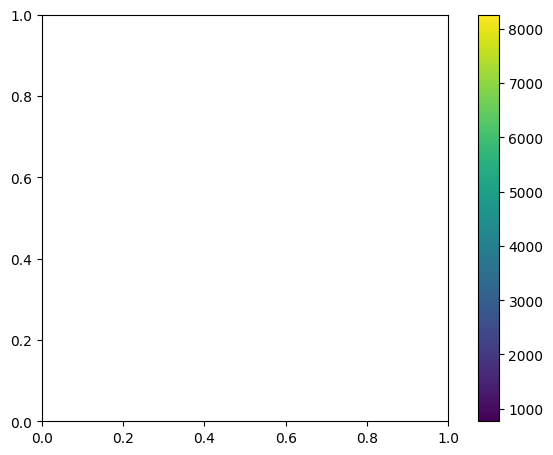

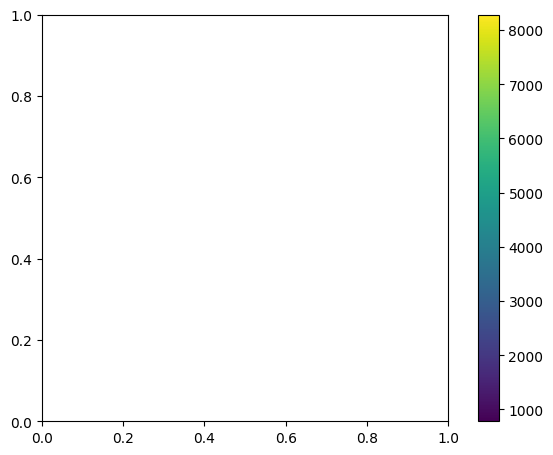

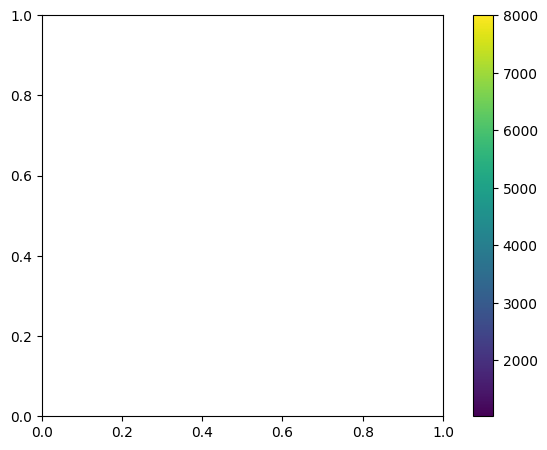

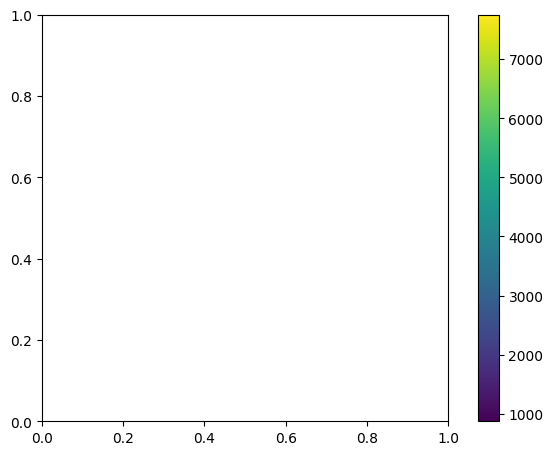

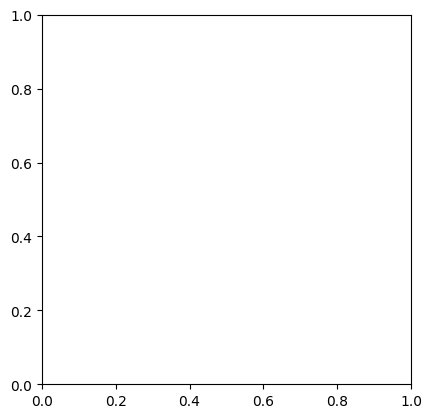

In [31]:
X = pd.concat([pd.DataFrame(X_reduced), pd.DataFrame(reviews_tfidf_reduced)], axis=1)

classification.classify(X_options=[X], y=y, filename='./model_report_using_all_data.xlsx', diagrams='./diagrams', append=False)

The best model trained can be found in the model_report_using_all_data.xlsx file and as it's shown it achieves a 0.9 f1 score.